In [1]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

cols = ["X2","X3","X1"] # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()

print(data.head())

         X2        X3        X1         Y    raw_x1    raw_x2    raw_x3
0  2.985660 -0.455945  0.902386  4.686122  0.650593  2.913862 -0.529439
1  2.183840  0.287470  0.274274  4.410815  0.162753  2.128470  0.232170
2  1.646134 -0.089969  1.195760  3.444338  0.878450  1.601779 -0.154506
3  1.815760  0.819613 -0.757854  3.378867 -0.638878  1.767930  0.777338
4  2.049346 -0.976188 -0.996825  3.135581 -0.824481  1.996731 -1.062414


In [2]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

N = X.shape[0]
P = X.shape[1]

In [3]:
import torch.nn as nn

embedding_dim = 8
dk = 4

random = torch.randn(
    embedding_dim,
    1,
    requires_grad=True
)

wq = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wk = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wv = torch.randn(
    embedding_dim,
    embedding_dim,
    requires_grad=True
)

proj = nn.Linear(
    embedding_dim,
    1
)

linear = nn.Linear(
    P,
    1
)

In [4]:
optimizer = torch.optim.Adam(

    [random,wq,wk,wv]

    +list(proj.parameters())

    +list(linear.parameters()),

    lr=0.001

)

In [6]:
import numpy as np
import torch.nn.functional as F

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    E = random.unsqueeze(0) * X.unsqueeze(1)

    Q = torch.matmul(
    wq.unsqueeze(0),
    E
    )

    K = torch.matmul(
    wk.unsqueeze(0),
    E
    )

    scores = torch.matmul(

    K.transpose(1,2),

    Q

    )

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=1
    )

    V = torch.matmul(
    wv.unsqueeze(0),
    E
    )

    delta_E = torch.matmul(
    V,
    attn
    )

    New_E = E + delta_E

    z = proj(
    New_E.transpose(1,2)
    )

    z = z.squeeze(-1)

    y_hat = linear(z)

    y_hat = y_hat.squeeze()

    loss = F.mse_loss(
    y_hat,
    y
    )

    if epoch == 0:
        initial_attn = attn.detach().clone()

        print(E.shape)

        print(Q.shape)

        print(K.shape)

        print(scores.shape)

        print(attn.shape)

        print(V.shape)

        print(delta_E.shape)

        print(New_E.shape)

        print(z.shape)

        print(y_hat.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    E = random.unsqueeze(0) * X.unsqueeze(1)

    Q = torch.matmul(
    wq.unsqueeze(0),
    E
    )

    K = torch.matmul(
    wk.unsqueeze(0),
    E
    )

    scores = torch.matmul(

    K.transpose(1,2),

    Q

    )

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=1
    )

    final_attn = attn.clone()




torch.Size([100, 8, 3])
torch.Size([100, 4, 3])
torch.Size([100, 4, 3])
torch.Size([100, 3, 3])
torch.Size([100, 3, 3])
torch.Size([100, 8, 3])
torch.Size([100, 8, 3])
torch.Size([100, 8, 3])
torch.Size([100, 3])
torch.Size([100])


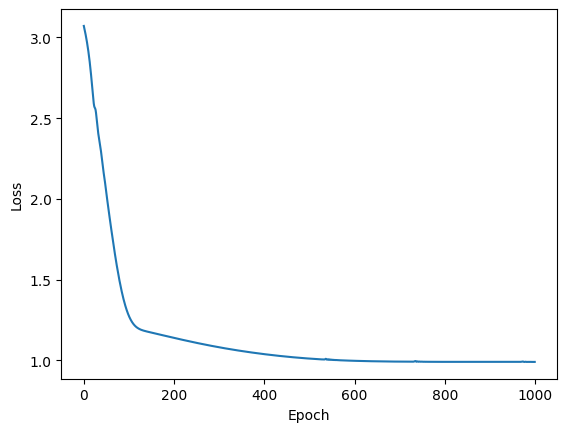

In [7]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

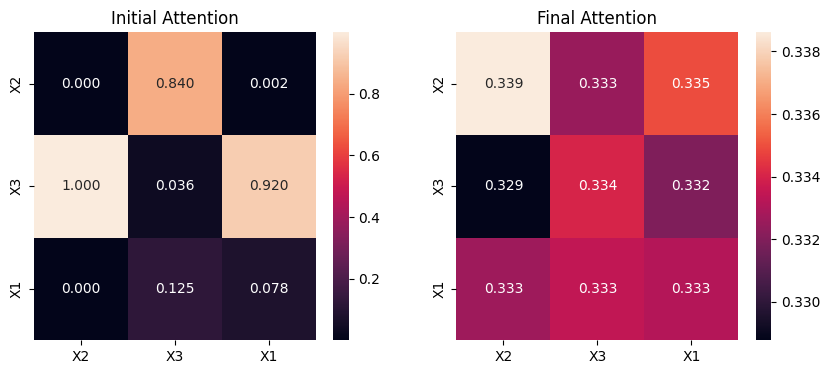

In [9]:
import seaborn as sns

# 設定變數名稱
labels = cols

id = 0

fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn[id].detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn[id].detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()